# Lab 1

## Business Understanding

This dataset was inspired by the 1987 Mushroom Dataset from the Audubon Society Field Guide. The Audubon Society is one of the most trusted voices in the world of nature and helps educate others through its research. A combination of scholars, scientists, field experts, and others helped compose their detailed 2023 guide on mushrooms. The original 1987 dataset consisted of 8,124 records with 23 different species, while the secondary mushroom dataset from 2023 expanded to 61,068 observations with 173 different species.

The most important outcome of our analysis would be the classification of whether a mushroom is edible or poisonous based on its physical attributes. This could be especially impactful for those who go foraging, as it could help prevent the consumption of poisonous mushrooms. Given that the secondary dataset contains a much larger number of observations and species, our results can hopefully be better generalized to the larger mushroom population. Overall, our hope is that others can gain useful knowledge from our analysis that helps them better identify whether mushrooms are safe to eat, which could ultimately help prevent future hospitalizations and even save lives.

For the specific goals of this project, an effective prediction algorithm would score well across each of the classification metrics, including accuracy, precision, specificity, sensitivity, and F1 score. However, because our primary concern is correctly identifying when a mushroom is poisonous (the positive class), we would prioritize sensitivity, therefore limiting the number of false negatives. In other words, we would especially want to avoid incorrectly classifying a poisonous mushroom as edible.

We would also value interpretability in our model when possible, with the goal of obtaining stable coefficients and a clear association statement.


## Importing

### Libraries

In [6]:
import numpy as np
import scipy
import sklearn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# import tensorflow as tf

### Mushroom Dataset into Python

In [7]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [8]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
secondary_mushroom = fetch_ucirepo(id=848) 
  
# data (as pandas dataframes) 
X_orig = secondary_mushroom.data.features 
y_orig = secondary_mushroom.data.targets 
  
# metadata 
print(secondary_mushroom.metadata) 
  
# variable information 
print(secondary_mushroom.variables) 

{'uci_id': 848, 'name': 'Secondary Mushroom', 'repository_url': 'https://archive.ics.uci.edu/dataset/848/secondary+mushroom+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/848/data.csv', 'abstract': 'Dataset of simulated mushrooms for binary classification into edible and poisonous.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 61068, 'num_features': 20, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2021, 'last_updated': 'Wed Apr 10 2024', 'dataset_doi': '10.24432/C5FP5Q', 'creators': ['Dennis Wagner', 'D. Heider', 'Georges Hattab'], 'intro_paper': {'ID': 259, 'type': 'NATIVE', 'title': 'Mushroom data creation, curation, and simulation to support classification tasks', 'authors': 'Dennis Wagner, D. Heider, Georges Hattab', 'venue': 'Scientific Reports', 'year': 2021, 'journal': None, '

In [9]:
X = X_orig.copy()
y = y_orig.copy()

In [10]:
X

,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,15.26,x,g,o,f,e,NaN,w,16.95,17.09,s,y,w,u,w,t,g,NaN,d,w
1,16.60,x,g,o,f,e,NaN,w,17.99,18.19,s,y,w,u,w,t,g,NaN,d,u
2,14.07,x,g,o,f,e,NaN,w,17.80,17.74,s,y,w,u,w,t,g,NaN,d,w
3,14.17,f,h,e,f,e,NaN,w,15.77,15.98,s,y,w,u,w,t,p,NaN,d,w
4,14.64,x,h,o,f,e,NaN,w,16.53,17.20,s,y,w,u,w,t,p,NaN,d,w
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61064,1.18,s,s,y,f,f,f,f,3.93,6.22,NaN,NaN,y,NaN,NaN,f,f,NaN,d,a
61065,1.27,f,s,y,f,f,f,f,3.18,5.43,NaN,NaN,y,NaN,NaN,f,f,NaN,d,a
61066,1.27,s,s,y,f,f,f,f,3.86,6.37,NaN,NaN,y,NaN,NaN,f,f,NaN,d,u
61067,1.24,f,s,y,f,f,f,f,3.56,5.44,NaN,NaN,y,NaN,NaN,f,f,NaN,d,u


Q: What does the value "f" mean for stem-root?

In [11]:
X_orig["stem-root"].unique()

<ArrowStringArray>
['s', nan, 'b', 'r', 'c', 'f']
Length: 6, dtype: str

In [12]:
y

,class
0,p
1,p
2,p
3,p
4,p
...,...
61064,p
61065,p
61066,p
61067,p


### Renaming the Attribute Values

In [13]:
# --------------------------------------------------
# Reusable definitions
# --------------------------------------------------

color_map = {
    "n": "brown",
    "b": "buff",
    "g": "gray",
    "r": "green",
    "p": "pink",
    "u": "purple",
    "e": "red",
    "w": "white",
    "y": "yellow",
    "l": "blue",
    "o": "orange",
    "k": "black",
    "f": "none"
}

surface_map = {
    "i": "fibrous",
    "g": "grooved",
    "y": "scaly",
    "s": "smooth",
    "h": "shiny",
    "l": "leathery",
    "k": "silky",
    "t": "sticky",
    "w": "wrinkled",
    "e": "fleshy",
    "f": "none"
}


# --------------------------------------------------
# Definitions for each categorical attribute
# --------------------------------------------------

value_definitions = {
    "cap-shape": {
        "b": "bell",
        "c": "conical",
        "x": "convex",
        "f": "flat",
        "s": "sunken",
        "p": "spherical",
        "o": "other"
    },

    "cap-surface": surface_map,

    "cap-color": color_map,

    "does-bruise-or-bleed": {
        "t": "bruises-or-bleeding",
        "f": "no"
    },

    "gill-attachment": {
        "a": "adnate",
        "x": "adnexed",
        "d": "decurrent",
        "e": "free",
        "s": "sinuate",
        "p": "pores",
        "f": "none",
        "?": "unknown"
    },

    "gill-spacing": {
        "c": "close",
        "d": "distant",
        "f": "none"
    },

    "gill-color": color_map,

    "stem-root": {
        "b": "bulbous",
        "s": "swollen",
        "c": "club",
        "u": "cup",
        "e": "equal",
        "z": "rhizomorphs",
        "r": "rooted"
    },

    "stem-surface": surface_map,

    "stem-color": color_map,

    "veil-type": {
        "p": "partial",
        "u": "universal"
    },

    "veil-color": color_map,

    "has-ring": {
        "t": "ring",
        "f": "none"
    },

    "ring-type": {
        "c": "cobwebby",
        "e": "evanescent",
        "r": "flaring",
        "g": "grooved",
        "l": "large",
        "p": "pendant",
        "s": "sheathing",
        "z": "zone",
        "y": "scaly",
        "m": "movable",
        "f": "none",
        "?": "unknown"
    },

    "spore-print-color": color_map,

    "habitat": {
        "g": "grasses",
        "l": "leaves",
        "m": "meadows",
        "p": "paths",
        "h": "heaths",
        "u": "urban",
        "w": "waste",
        "d": "woods"
    },

    "season": {
        "s": "spring",
        "u": "summer",
        "a": "autumn",
        "w": "winter"
    }
}


# --------------------------------------------------
# Rename the values in the working data
# --------------------------------------------------

for column, definitions in value_definitions.items():
    if column in X.columns:
        X[column] = X[column].replace(definitions)

# Rename the target values
y["class"] = y["class"].replace({
    "e": "edible",
    "p": "poisonous"
})


# --------------------------------------------------
# Combine renamed features and target
# --------------------------------------------------

data = pd.concat([X, y], axis=1)

display(data.head())

,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,...,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season,class
0,15.26,convex,grooved,orange,no,free,NaN,white,16.95,17.09,...,scaly,white,universal,white,ring,grooved,NaN,woods,winter,poisonous
1,16.60,convex,grooved,orange,no,free,NaN,white,17.99,18.19,...,scaly,white,universal,white,ring,grooved,NaN,woods,summer,poisonous
2,14.07,convex,grooved,orange,no,free,NaN,white,17.80,17.74,...,scaly,white,universal,white,ring,grooved,NaN,woods,winter,poisonous
3,14.17,flat,shiny,red,no,free,NaN,white,15.77,15.98,...,scaly,white,universal,white,ring,pendant,NaN,woods,winter,poisonous
4,14.64,convex,shiny,orange,no,free,NaN,white,16.53,17.20,...,scaly,white,universal,white,ring,pendant,NaN,woods,winter,poisonous


## Data Understanding

### 1. Describe the meaning and type of data (scale, values, etc.) for each attribute in the data file.

Data Types

In [14]:
print(data.dtypes)

cap-diameter            float64
cap-shape                   str
cap-surface                 str
cap-color                   str
does-bruise-or-bleed        str
gill-attachment             str
gill-spacing                str
gill-color                  str
stem-height             float64
stem-width              float64
stem-root                   str
stem-surface                str
stem-color                  str
veil-type                   str
veil-color                  str
has-ring                    str
ring-type                   str
spore-print-color           str
habitat                     str
season                      str
class                       str
dtype: object


The scales for the numeric attributes are as follows: cap-diameter (cm), stem-height (cm), and stem-width (mm). The categorical variables are all nominal without a specific ordinality tied to them



### Setting Numeric Features vs Categorical Features

In [15]:
numeric_features = [
    "cap-diameter",
    "stem-height",
    "stem-width"
]

categorical_features = [
    column for column in X.columns
    if column not in numeric_features
]

### 2. Verify data quality: Explain any missing values, duplicate data, and outliers. Are those mistakes? How do you deal with these problems? Be specific.

NA Values

In [16]:
# Missing-value count for each feature column
X.isna().sum()

cap-diameter                0
cap-shape                   0
cap-surface             14120
cap-color                   0
does-bruise-or-bleed        0
gill-attachment          9884
gill-spacing            25063
gill-color                  0
stem-height                 0
stem-width                  0
stem-root               51538
stem-surface            38124
stem-color                  0
veil-type               57892
veil-color              53656
has-ring                    0
ring-type                2471
spore-print-color       54715
habitat                     0
season                      0
dtype: int64

In [17]:
na_summary = pd.DataFrame({
    "NA Count": data.isna().sum(),
    "NA Percentage": (data.isna().mean() * 100).round(2)
})

display(na_summary)

,NA Count,NA Percentage
cap-diameter,0,0.00
cap-shape,0,0.00
cap-surface,14120,23.12
cap-color,0,0.00
does-bruise-or-bleed,0,0.00
gill-attachment,9884,16.18
gill-spacing,25063,41.04
gill-color,0,0.00
stem-height,0,0.00
stem-width,0,0.00


looking at the unique values of each categorical feature

In [18]:
print(X["stem-root"].unique())
print(X["veil-type"].unique())
print(X["veil-color"].unique())
print(X["spore-print-color"].unique())

<ArrowStringArray>
['swollen', nan, 'bulbous', 'rooted', 'club', 'f']
Length: 6, dtype: str
<ArrowStringArray>
['universal', nan]
Length: 2, dtype: str
<ArrowStringArray>
['white', 'yellow', nan, 'brown', 'red', 'purple', 'black']
Length: 7, dtype: str
<ArrowStringArray>
[nan, 'white', 'pink', 'black', 'green', 'purple', 'brown', 'gray']
Length: 8, dtype: str


Duplicate Data

In [19]:
# Number and percentage of duplicate rows
duplicate_count = data.duplicated().sum()


duplicate_percentage = duplicate_count / len(data) * 100

print("Duplicate rows:", duplicate_count)
print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

#Note: duplicate rows are not removed in this analysis, as they may represent valid observations in the dataset.

Duplicate rows: 146
Duplicate percentage: 0.24%


Outliers

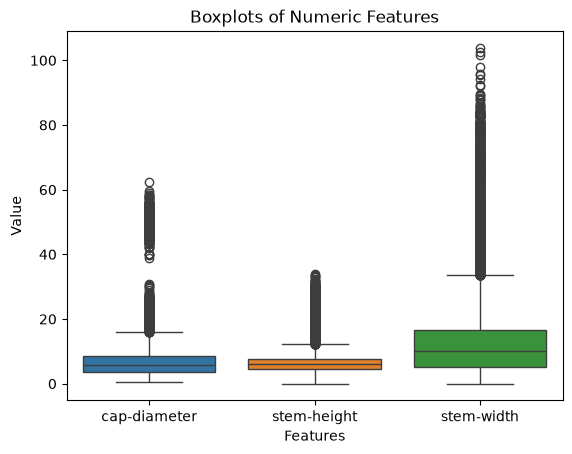

In [20]:
sns.boxplot(data=X[numeric_features])

plt.title("Boxplots of Numeric Features")
plt.xlabel("Features")
plt.ylabel("Value")
plt.show()

### 3. Give simple, appropriate statistics (range, mode, mean, median, variance, counts, etc.) for the most important attributes and describe what they mean or if you found something interesting. Note: You can also use data from other sources for comparison. Explain the significance of the statistics run and why they are meaningful.

Numerical Attributes

In [21]:
numerical_summary = X[numeric_features].describe().T.round(2)
display(numerical_summary)

,count,mean,std,min,25%,50%,75%,max
cap-diameter,61069.0,6.73,5.26,0.38,3.48,5.86,8.54,62.34
stem-height,61069.0,6.58,3.37,0.00,4.64,5.95,7.74,33.92
stem-width,61069.0,12.15,10.04,0.00,5.21,10.19,16.57,103.91


Categorial Attributes

In [22]:
categorical_summary = X[categorical_features].describe().T
display(categorical_summary)

,count,unique,top,freq
cap-shape,61069,7,convex,26934
cap-surface,46949,11,sticky,8196
cap-color,61069,12,brown,24218
does-bruise-or-bleed,61069,2,no,50479
gill-attachment,51185,7,adnate,12698
gill-spacing,36006,3,close,24710
gill-color,61069,12,white,18521
stem-root,9531,5,swollen,3177
stem-surface,22945,8,smooth,6025
stem-color,61069,13,white,22926


Looking at Class Comparison for Numerical Attributes

In [23]:
data = pd.concat([X, y], axis=1)

group_summary = (
    data.groupby("class")[numeric_features]
    .describe()
)

display(group_summary.round(2))

cap-diameter                                            stem-height  \
                 count  mean   std   min   25%   50%   75%    max       count   
class                                                                           
edible         27181.0  7.80  6.37  0.53  4.29  6.71  9.41  62.34     27181.0   
poisonous      33888.0  5.88  3.97  0.38  3.04  4.98  7.85  30.34     33888.0   

                 ...              stem-width                                   \
           mean  ...   75%    max      count   mean    std   min   25%    50%   
class            ...                                                            
edible     7.04  ...  7.74  33.92    27181.0  14.36  11.04  0.74  7.13  12.59   
poisonous  6.21  ...  7.74  20.19    33888.0  10.38   8.75  0.00  3.58   7.66   

                          
             75%     max  
class                     
edible     18.39  103.91  
poisonous  14.34   58.95  

[2 rows x 24 columns]

### 4. Visualize the most important attributes appropriately (at least 5 attributes). Important: Provide an interpretation for each chart. Explain for each attribute why the chosen visualization is appropriate.

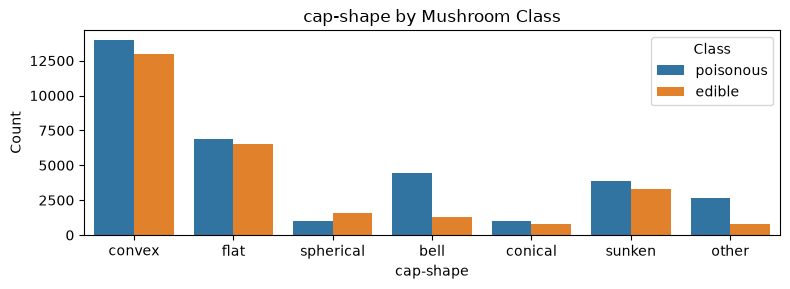

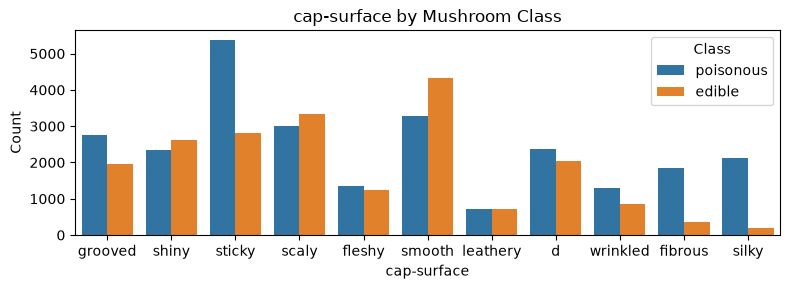

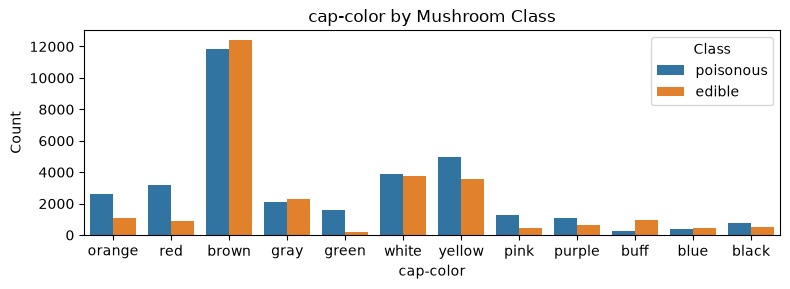

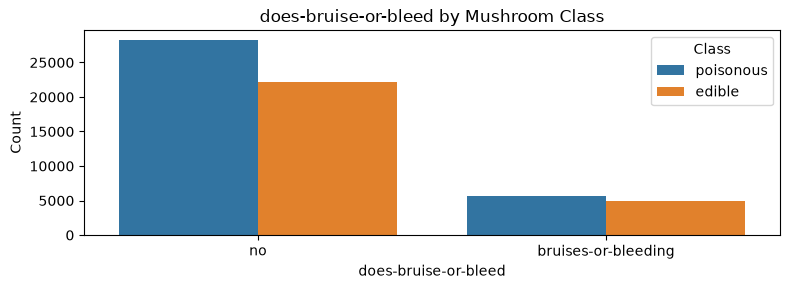

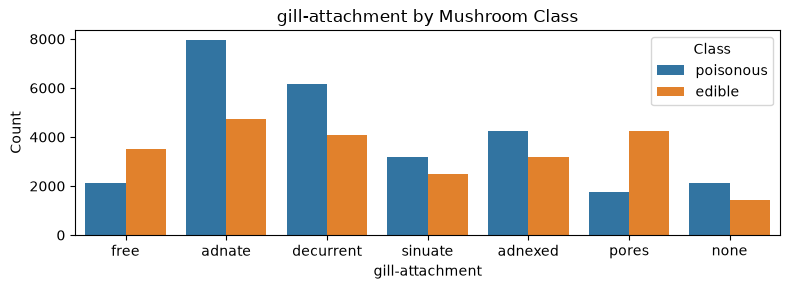

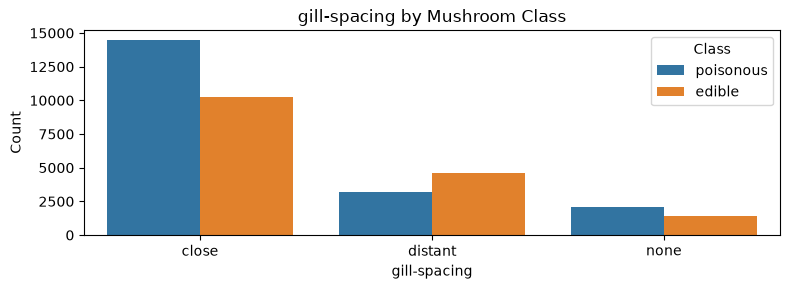

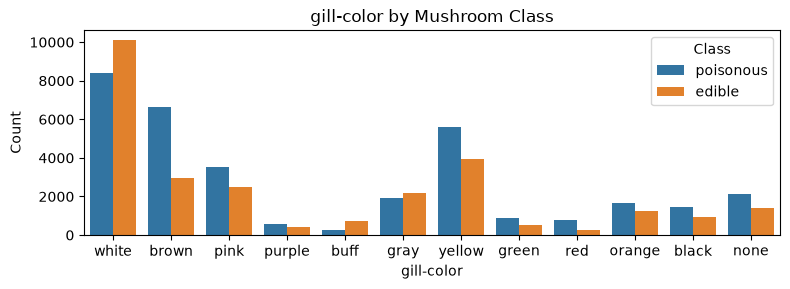

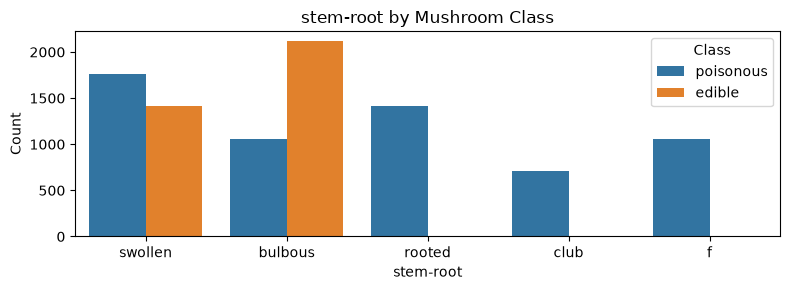

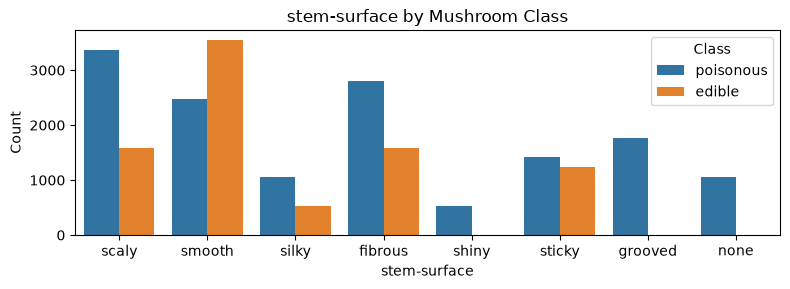

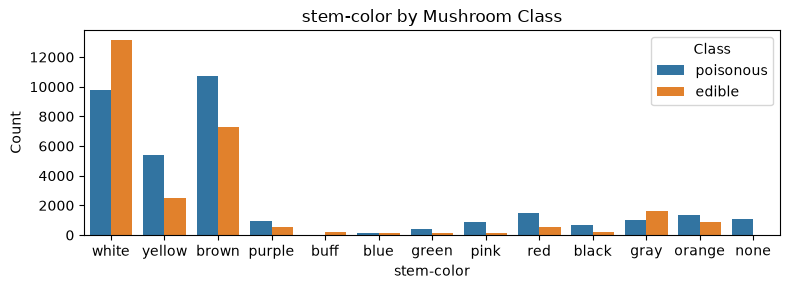

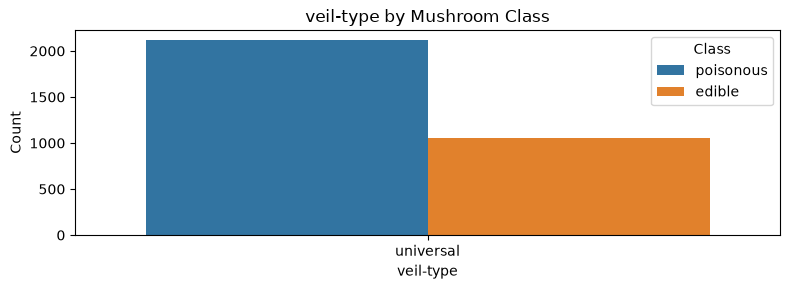

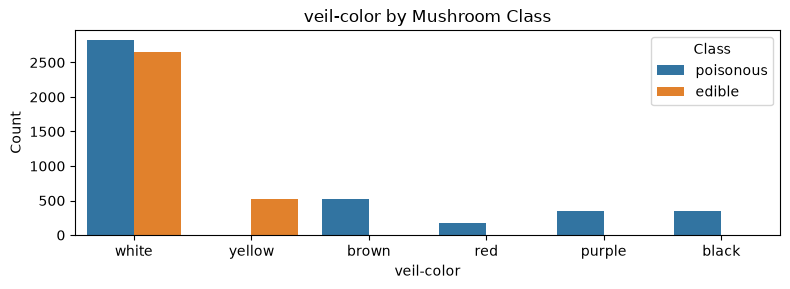

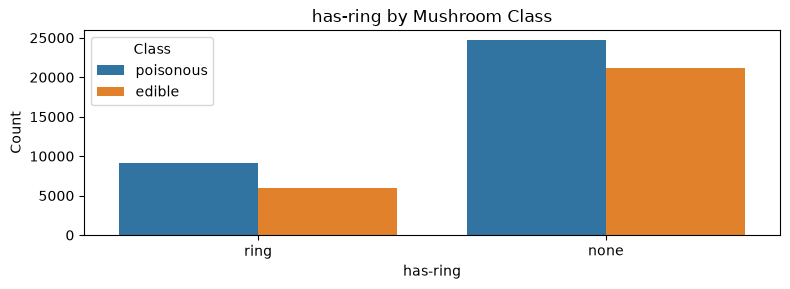

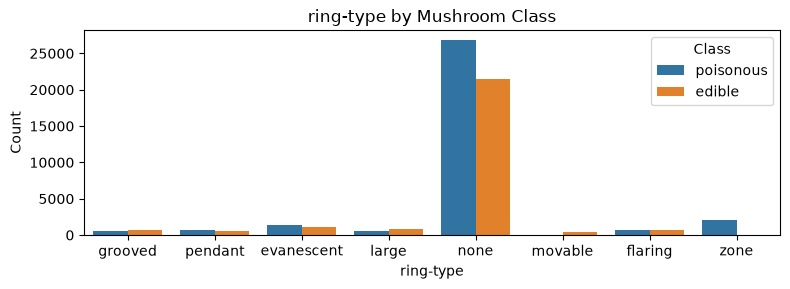

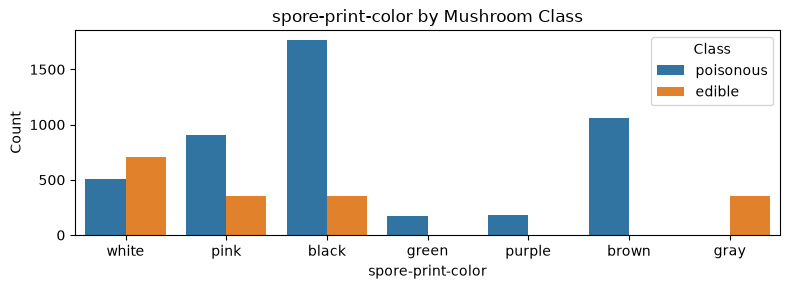

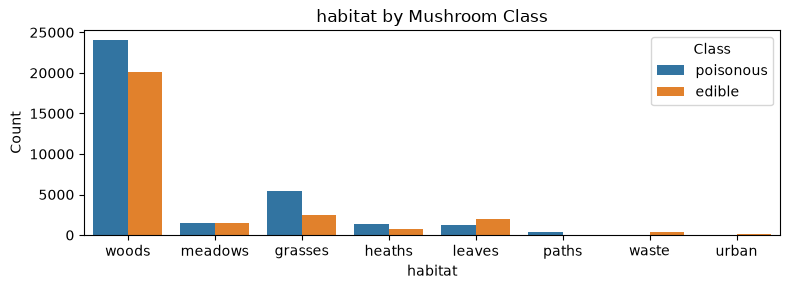

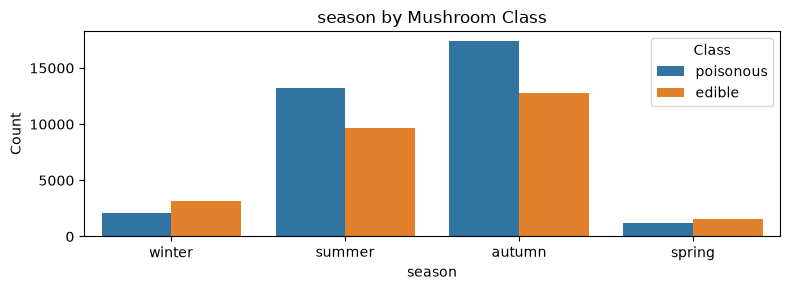

In [24]:
for col in categorical_features:
    plt.figure(figsize=(8, 3))
    sns.countplot(data=data, x=col, hue="class")
    plt.title(f"{col} by Mushroom Class")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Class")
    plt.tight_layout()
    plt.show()

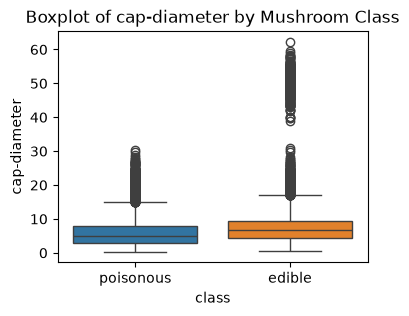

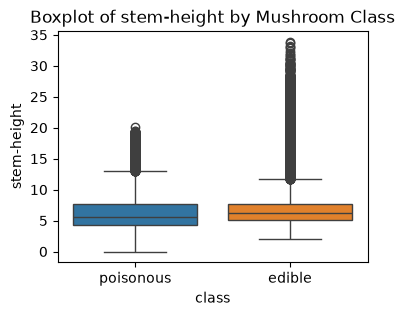

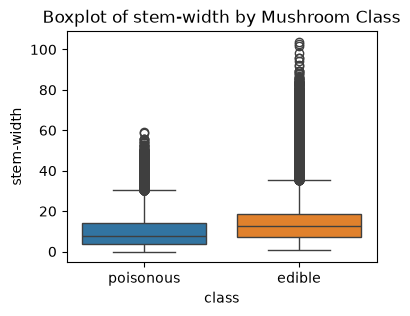

In [25]:
for col in data[numeric_features].columns:
    plt.figure(figsize=(4, 3))
    sns.boxplot(x = "class", y = col, data = data, hue = "class")
    plt.title(f"Boxplot of {col} by Mushroom Class")
    plt.show()

### 5. Explore relationships between attributes: Look at the attributes via scatter plots, correlation, cross-tabulation, group-wise averages, etc. as appropriate. Explain any interesting relationships.

Scatterplots between numeric attributes

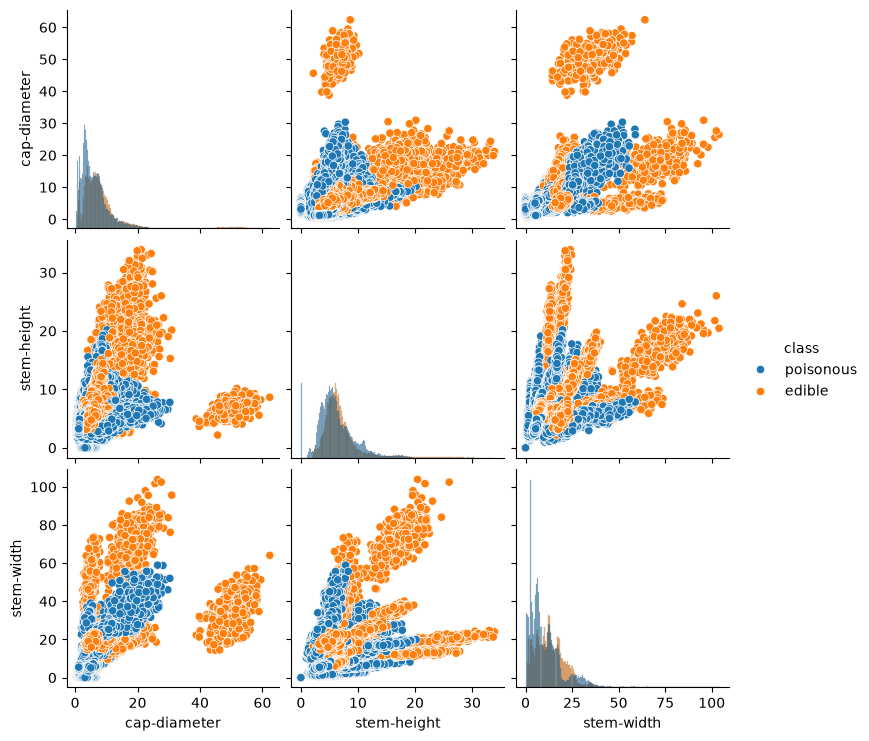

In [26]:
sns.pairplot(
    data,
    vars=numeric_features,
    hue="class",
    diag_kind="hist"
)

plt.show()

Correlation heatmap

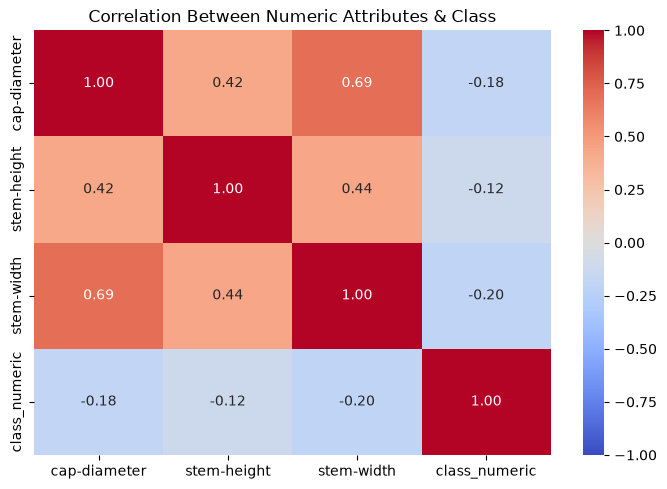

In [27]:

# Create a separate copy for correlation analysis
correlation_data = data.copy()

# Encode the target
correlation_data["class_numeric"] = (
    correlation_data["class"].map({
        "edible": 0,
        "poisonous": 1
    })
)

correlation_columns = [
    "cap-diameter",
    "stem-height",
    "stem-width",
    "class_numeric"
]
correlation_matrix = correlation_data[correlation_columns].corr().round(3)

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    fmt=".2f"
)

plt.title("Correlation Between Numeric Attributes & Class")
plt.tight_layout()
plt.show()

Stem color and mushroom class

In [28]:
stem_color_table = pd.crosstab(
    data["stem-color"],
    data["class"],
    normalize="index"
).mul(100).round(2)

stem_color_table["count"]  = data["stem-color"].value_counts().reindex(stem_color_table.index)

display(stem_color_table)

class,edible,poisonous,count
stem-color,,,
black,22.58,77.42,837
blue,46.46,53.54,226
brown,40.46,59.54,18063
buff,100.00,0.00,173
gray,60.70,39.30,2626
green,21.03,78.97,542
none,0.00,100.00,1059
orange,39.23,60.77,2187
pink,12.88,87.12,1025


Stem color & has-ring by mushroom class

In [29]:
stem_color_ring_table = pd.crosstab(
    index=data["stem-color"],
    columns=[data["has-ring"], 
             data["class"]],
    normalize="index"
).mul(100).round(2)

display(stem_color_ring_table)

has-ring      none             ring          
class       edible poisonous edible poisonous
stem-color                                   
black        22.58     77.42   0.00      0.00
blue         46.46      0.00   0.00     53.54
brown        29.72     48.69  10.73     10.85
buff        100.00      0.00   0.00      0.00
gray         53.77     39.30   6.93      0.00
green        21.03     78.97   0.00      0.00
none          0.00     66.67   0.00     33.33
orange       39.23     45.27   0.00     15.50
pink         12.88     52.68   0.00     34.44
purple       35.77     64.23   0.00      0.00
red          26.24     67.41   0.00      6.34
white        42.78     23.68  14.55     19.00
yellow       24.78     48.37   6.93     19.92

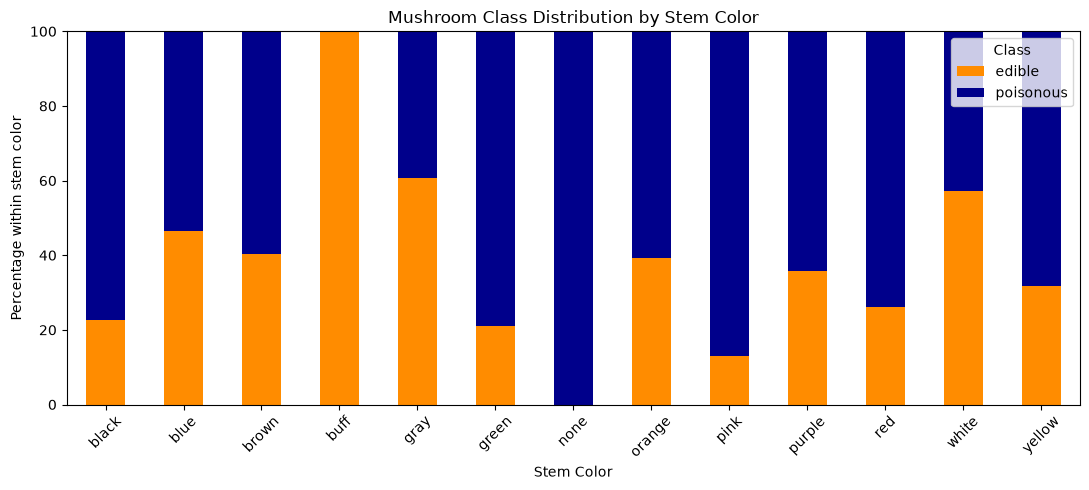

In [30]:
stem_color_table[["edible", "poisonous"]].plot(
    kind="bar",
    stacked=True,
    figsize=(11, 5),
    color=["darkorange", "darkblue"]
)

plt.title("Mushroom Class Distribution by Stem Color")
plt.xlabel("Stem Color")
plt.ylabel("Percentage within stem color")
plt.legend(title="Class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6. Identify and explain interesting relationships between features and the class you are trying to predict (i.e., relationships with variables and the target classification).

The analysis identified relationships between both numerical and categorical features and mushroom class. Edible mushrooms generally had larger caps, taller stems, and wider stems, with stem width showing the strongest numerical relationship with class. However, the correlations were relatively weak and the class distributions overlapped substantially. Stem color showed clearer differences in class proportions, with several colors strongly associated with the poisonous class. Ring presence also appeared to modify the relationship between certain stem colors and class. Overall, no single feature was sufficient to separate edible and poisonous mushrooms, indicating that an effective classifier should combine multiple numerical and categorical characteristics.

### 7. Are there other features that could be added to the data or created from existing features? Which ones?

Given the correlation among the numerical attributes (which made intuitive sense since they were size-related), we could take into account stem-height, stem-width, and cap-diameter and generate a combined size feature that's some kind of ratio of the three numerical attributes. Another feature we could create is one that indicates "True" or "False" if the cap color and the stem color match, which could prove to be effective in helping to predict class.

## Exceptional Work

PCA Dimensionality Reduction

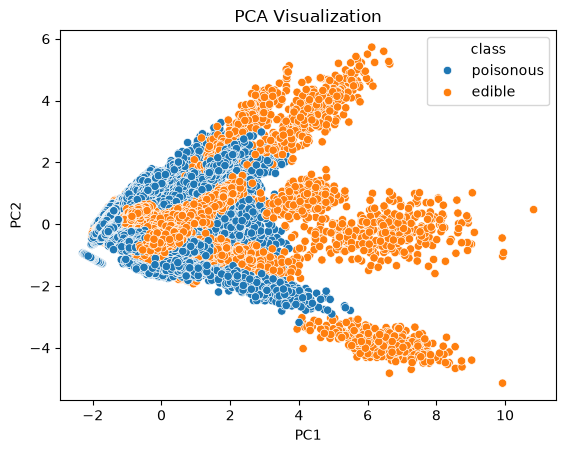

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select numeric data
X_numeric = data[numeric_features]

# Standardize the variables
X_scaled = StandardScaler().fit_transform(X_numeric)

# Reduce from three dimensions to two
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Store the results
pca_data = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_data["class"] = data["class"].values

sns.scatterplot(data=pca_data, x="PC1", y="PC2", hue="class")
plt.title("PCA Visualization")
plt.show()